In [117]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PageRank


## Introduction ##


### **PageRank (PR)** is an algorithm used by Google Search to rank web pages in their search engine results. ###

### It is named after both the term "web page" and co-founder [Larry Page](https://en.wikipedia.org/wiki/Larry_Page). ###

### PageRank is a way of measuring the importance of website pages. ###



### According to Google: ###


#### _PageRank works by counting the number and quality of links to a page to determine a rough estimate of how important the website is._ ####

#### _The underlying assumption is that more important websites are likely to receive more links from other websites._ ####




## Algorithm Description ## 


### **PageRank** is a link analysis algorithm that assigns a numerical weighting to each element of a hyperlinked set of documents, with the purpose of measuring its relative importance within the set. ###
### The algorithm may be applied to any collection of entities with reciprocal quotations and references. ###
### The numerical weight that it assigns to any given element $E$ is referred to as the _PageRank_ of $E$ and denoted by $PR(E)$. ###
### A _PageRank_ results from a mathematical algorithm based on the [Webgraph](https://en.wikipedia.org/wiki/Webgraph), created by all World Wide Web pages as nodes and hyperlinks as edges. ###
### The rank value indicates an importance of a particular page. A hyperlink to a page counts as a vote of support. ###
### The _PageRank_ of a page is defined recursively and depends on the number and PageRank metric of all pages that link to it ("incoming links"). ###
### A page that is linked to by many pages with high _PageRank_ receives a high rank itself. ###

In [40]:
def pagerank(M, d: float = 0.85):
    """PageRank algorithm with explicit number of iterations. Returns ranking of nodes (pages) in the adjacency matrix.

    Parameters
    ----------
    M : numpy array, mandatory
        adjacency matrix where M_i,j represents the link from 'j' to 'i', such that for all 'j'
        sum(i, M_i,j) = 1
    d : float, optional
        damping factor, by default 0.85

    Returns
    -------
    numpy array
        a vector of ranks such that v_i is the i-th rank from [0, 1],

    """
    # N = Number of pages (nodes)
    N = M.shape[1]
    
    # w = Initial rank vector
    # We assume all pages are equally important
    w = np.ones(N) / N

    # Applying the damping factor
    # Represents the probability a user follows a link
    M_hat = d * M

    # Page rank received from incoming links
    link_contribution = M_hat @ w

    # Probability of randomly jumping to any page.
    # Adds small probability to every page
    teleportation_probability = (1 - d) / N

    # First rank update
    v = link_contribution + teleportation_probability
    
    # Algorithm runs until convergence
    # w - old rank
    # v - new rank
    # Repeating until difference is smaller than 1e-10
    while np.linalg.norm(w - v) >= 1e-10:
        # Update old vector
        w = v

        # Recalculate rank
        v = M_hat @ w + (1 - d) / N
    
    # Return final PageRank vector
    return v

In [64]:
# The matrix is always square, because it represents transitions between the same set of pages
# Every column must sum to 1
M = np.array([
    [0.0, 0.5, 0.0, 0.0, 0.2, 0.1],
    [0.5, 0.0, 0.3, 0.0, 0.2, 0.2],
    [0.5, 0.0, 0.0, 0.5, 0.2, 0.0],
    [0.0, 0.5, 0.4, 0.0, 0.0, 0.3],
    [0.0, 0.0, 0.3, 0.5, 0.3, 0.3],
    [0.0, 0.0, 0.0, 0.0, 0.1, 0.1]
])

In [62]:
def is_markov_matrix(matrix):
    """
    Checks if the given square matrix is a valid Markov chain matrix.
    A valid Markov matrix has:
    - Each column sums to 1
    - All entries are non-negative
    """
    matrix = np.array(matrix)
    
    # Check if square
    if matrix.shape[0] != matrix.shape[1]:
        return False
    
    # Check non-negative entries
    if np.any(matrix < 0):
        return False
    
    # Check column sums
    col_sums = matrix.sum(axis = 0)
    return np.allclose(col_sums, 1.0)

In [65]:
# Check if the matrix webgraph is a Markov matrix
# This check can be moved also inside pagerank function as a guard clause, but want to keep it concentrated only on calculating the rank
is_markov_matrix(M)

True

In [70]:
page_rank_result = pagerank(M)

In [73]:
def is_valid_pagerank(v, tol=1e-10):
    """
    Check if a vector v is a valid PageRank vector.

    Parameters
    ----------
    v : numpy array
        The PageRank vector to check.
    tol : float
        Tolerance for sum to 1 (default 1e-10).

    Returns
    -------
    bool
        True if v is a valid PageRank vector, False otherwise.
    """
    v = np.asarray(v)

    # 1. All entries non-negative
    if np.any(v < 0):
        return False

    # 2. Sum close to 1
    if not np.isclose(np.sum(v), 1, atol=tol):
        return False

    # 3. Not empty
    if v.size == 0:
        return False

    return True

In [72]:
# Checking if the result is a valid PageRank vector
is_valid_pagerank(page_rank_result)

True

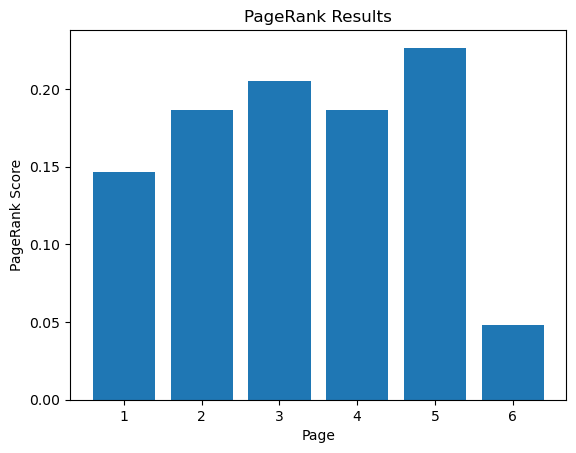

In [110]:
pages = np.arange(1, len(page_rank_result) + 1)

plt.bar(pages, page_rank_result)

plt.xlabel("Page")
plt.ylabel("PageRank Score")
plt.title("PageRank Results")

plt.xticks(pages)

plt.show()

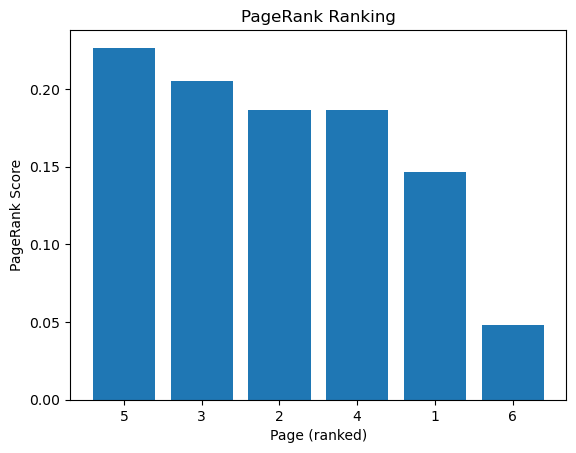

In [108]:
sorted = np.argsort(page_rank_result)[::-1]

plt.bar(range(len(page_rank_result)), page_rank_result[sorted])
plt.xticks(range(len(page_rank_result)), sorted + 1)

plt.xlabel("Page (ranked)")
plt.ylabel("PageRank Score")
plt.title("PageRank Ranking")

plt.show()

In [158]:
def generate_webgraph_matrix(N, sparsity = 0.4, seed = None):
    """
    Generate a random N x N PageRank matrix (stochastic columns).

    Parameters
    ----------
    N : int
        Number of pages (nodes), must be >= 2
    sparsity : float, optional
        Approximate fraction of zero links per column (0 to 1). Default 0.3
    seed : int, optional
        Random seed for reproducibility

    Returns
    -------
    M : np.ndarray
        N x N stochastic matrix (columns sum to 1)
    """
    if N < 2:
        raise ValueError("Number of pages must be >= 2")
    
    if seed is not None:
        np.random.seed(seed)
    
    M = np.zeros((N, N))
    
    for j in range(N):
        # Random links with sparsity
        link_mask = np.random.rand(N) > sparsity  # True = link exists
        if not np.any(link_mask):
            # Ensure at least one link to avoid dead column
            link_mask[np.random.randint(0, N)] = True
        
        # Random weights for existing links
        weights = np.random.rand(np.sum(link_mask))
        weights = weights / np.sum(weights)  # normalize to sum 1
        
        M[link_mask, j] = weights
    
    return M

In [175]:
generated_webgraph_matrix = generate_webgraph_matrix(10000, sparsity = 0.7, seed = 42)

In [176]:
# Check if it is a valid Markov matrix
is_markov_matrix(generated_webgraph_matrix)

True

In [177]:
webgraph_matrix_result = pagerank(generated_webgraph_matrix)

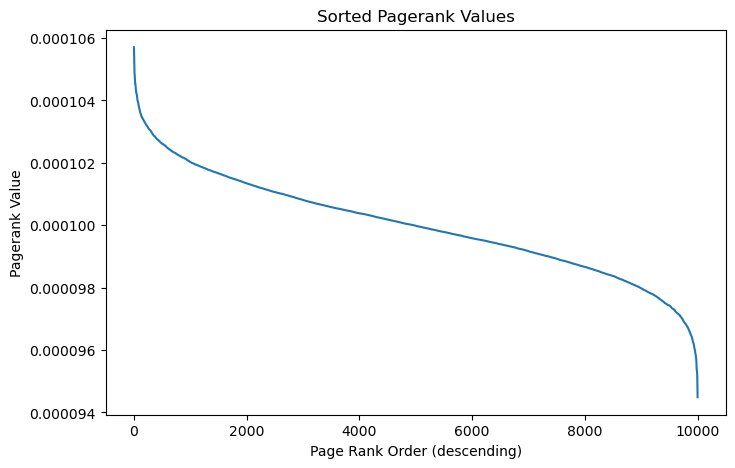

In [178]:
# Pagerank is skewed so we are sorting to see it clearly
sorted_pr = np.sort(webgraph_matrix_result)[::-1]

plt.figure(figsize=(8,5))
plt.plot(sorted_pr)
plt.xlabel('Page Rank Order (descending)')
plt.ylabel('Pagerank Value')
plt.title('Sorted Pagerank Values')
plt.show()